In [18]:
import os
import cv2
import albumentations as A

import glob
from PIL import Image
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.utils as vutils
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### Качаем веса моделей 

In [5]:
!pip install gdown -q

# Скачивание файлов
!gdown --id 1cobZn8shii6V9x33Y0Ek99DMeAaHFYIE # resro
!gdown --id 1mM89qAepXUlbKhL7u9tcwYBvP1VpMpf2 # gen

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1cobZn8shii6V9x33Y0Ek99DMeAaHFYIE
To: /kaggle/working/final_restoration_model.pth
100%|██████████████████████████████████████| 5.34M/5.34M [00:00<00:00, 35.4MB/s]
/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1mM89qAepXUlbKhL7u9tcwYBvP1VpMpf2
From (redirected): https://drive.google.com/uc?id=1mM89qAepXUlbKhL7u9tcwYBvP1VpMpf2&confirm=t&uuid=c816731c-b6df-40c7-bf5a-d447aae59042
To: /kaggle/working/final_G_coloration_model.pth
100%|█████████████████████████████████████████| 124M/124M [00

### Модель реставрации 

In [6]:
class DenseLayer(nn.Module):
    def __init__(self, in_channels, growth_rate):
        super(DenseLayer, self).__init__()
        self.conv = nn.Conv2d(in_channels, growth_rate, kernel_size=3, padding=1)
        self.relu = nn.ReLU(inplace=True)
        
    def forward(self, x):
        out = self.conv(x)
        out = self.relu(out)
        out = torch.cat([x, out], dim=1)
        return out

In [7]:
class ResidualDenseBlock(nn.Module):
    def __init__(self, in_channels, growth_rate=32, n_units=4):
        super(ResidualDenseBlock, self).__init__()
        
        self.units = nn.ModuleList()
        curr_channels = in_channels
        
        for _ in range(n_units):
            self.units.append(DenseLayer(curr_channels, growth_rate))
            curr_channels += growth_rate
        
        self.lff = nn.Conv2d(curr_channels, in_channels, kernel_size=1)
        
    def forward(self, x):
        residual = x
        out = x
        
        for unit in self.units:
            out = unit(out)
        
        out = self.lff(out)
        out = residual + out
        return out

class ResidualDenseBlockGroup(nn.Module):
    def __init__(self, in_channels, growth_rate=32, n_blocks=3, n_units_per_block=4):
        super(ResidualDenseBlockGroup, self).__init__()
        
        self.blocks = nn.ModuleList()
        for _ in range(n_blocks):
            self.blocks.append(ResidualDenseBlock(in_channels, growth_rate, n_units_per_block))
    
    def forward(self, x):
        out = x
        for block in self.blocks:
            out = block(out)
        return out

In [8]:
class MultiLevelRDN(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, growth_rate=32):
        super(MultiLevelRDN, self).__init__()
        
        self.initial_conv = nn.Conv2d(in_channels, 64, kernel_size=3, padding=1)
        
        self.level1_group = ResidualDenseBlockGroup(64, growth_rate, n_blocks=3)
        self.level2_group = ResidualDenseBlockGroup(64, growth_rate, n_blocks=3)
        self.level3_group = ResidualDenseBlockGroup(64, growth_rate, n_blocks=3)
        
        self.gff = nn.Sequential(
            nn.Conv2d(64 * 3, 64, kernel_size=1),
            nn.Conv2d(64, 64, kernel_size=3, padding=1)
        )
        
        self.output_conv = nn.Conv2d(64, out_channels, kernel_size=3, padding=1)
        self.global_skip = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        
    def forward(self, x):
        skip = self.global_skip(x)
        shallow = self.initial_conv(x)
        
        level1_out = self.level1_group(shallow)
        
        down_4x = F.interpolate(shallow, scale_factor=0.25, mode='bilinear', align_corners=False)
        level2_out = self.level2_group(down_4x)
        level2_out = F.interpolate(level2_out, size=shallow.shape[2:], mode='bilinear', align_corners=False)
        
        down_8x = F.interpolate(shallow, scale_factor=0.125, mode='bilinear', align_corners=False)
        level3_out = self.level3_group(down_8x)
        level3_out = F.interpolate(level3_out, size=shallow.shape[2:], mode='bilinear', align_corners=False)
        
        fused = torch.cat([level1_out, level2_out, level3_out], dim=1)
        fused = self.gff(fused)
        
        out = self.output_conv(fused)
        out = out + skip
        
        return out

In [9]:
restoration_model = MultiLevelRDN()
restoration_state_dict = torch.load('final_restoration_model.pth')
restoration_model.load_state_dict(restoration_state_dict)

restoration_model = restoration_model.to(DEVICE)

### Модель колоризации 

In [10]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size = 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.LeakyReLU(0.2),
            nn.Conv2d(out_channels, out_channels, kernel_size = 3, padding=1, bias=False), 
            nn.BatchNorm2d(out_channels),
            nn.LeakyReLU(0.2),
        )

    def forward(self, x):
        return self.conv(x)

class UNetGenerator(nn.Module):
    def __init__(self, in_channels=1, out_channels=2, features=[64, 128, 256, 512]):
        super(UNetGenerator, self).__init__()
        self.downs = nn.ModuleList()
        self.ups = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Enc
        in_feat = in_channels
        for feature in features:
            self.downs.append(DoubleConv(in_feat, feature))
            in_feat = feature

        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)

        # Dec
        for feature in reversed(features):
            self.ups.append(
                nn.ConvTranspose2d(feature * 2, feature, kernel_size=2, stride=2)
            )
            self.ups.append(DoubleConv(feature * 2, feature))

        self.final_conv = nn.Sequential(
            nn.Conv2d(features[0], out_channels, kernel_size=1),
            nn.Tanh()
        )

    def forward(self, x):
        skip_connections = []

        for down in self.downs:
            x = down(x)
            skip_connections.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)
        skip_connections = skip_connections[::-1]

        for idx in range(0, len(self.ups), 2):
            x = self.ups[idx](x)
            skip_connection = skip_connections[idx // 2]
            concat_skip = torch.cat((skip_connection, x), dim=1)
            x = self.ups[idx + 1](concat_skip)

        return self.final_conv(x)

In [11]:
colorization_model = UNetGenerator()
coloration_state_dict = torch.load('final_G_coloration_model.pth')
colorization_model.load_state_dict(coloration_state_dict)

colorization_model = colorization_model.to(DEVICE)

In [13]:
def compute_grayscale_scores(folder_path):
    scores = {}
    
    files = [
        os.path.join(folder_path, f) 
        for f in os.listdir(folder_path)
    ]
    
    for img_path in files:
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        arr = np.array(img)
        
        r = arr[:, :, 0].astype(np.int32)
        g = arr[:, :, 1].astype(np.int32)
        b = arr[:, :, 2].astype(np.int32)
        
        diff_rg = np.abs(r - g)
        diff_rb = np.abs(r - b)
        diff_gb = np.abs(g - b)
        
        score = np.mean([diff_rg, diff_rb, diff_gb])
        scores[img_path] = float(score)
    
    return scores

def filter_grayscale_by_threshold(folder_path, threshold):
    scores = compute_grayscale_scores(folder_path)
    
    filtered_paths = [
        path for path, score in scores.items() 
        if score >= threshold
    ]
    
    return filtered_paths

In [14]:
class FullRestorationDataset(Dataset):
    def __init__(self, degraded_dir, pristine_dir, image_size=256):
        self.degraded_dir = degraded_dir
        self.pristine_dir = pristine_dir
        self.image_size = image_size

        self.pristine_paths = filter_grayscale_by_threshold(pristine_dir, 15.6)
        self.pristine_paths = sorted(self.pristine_paths)
        

        self.degraded_paths = [
            os.path.join(self.degraded_dir, os.path.basename(d)) 
            for d in self.pristine_paths
        ]
        self.pristine_paths = sorted(self.pristine_paths)
        
        print(f"All images will be resized to {image_size}x{image_size}")
        
    def __len__(self):
        return len(self.degraded_paths)
    
    def __getitem__(self, idx):
        degraded = Image.open(self.degraded_paths[idx]).convert('L')
        pristine = Image.open(self.pristine_paths[idx]).convert('RGB')
        
        # Ресайз
        degraded = degraded.resize((self.image_size, self.image_size), Image.BICUBIC)
        pristine = pristine.resize((self.image_size, self.image_size), Image.BICUBIC)
        
        degraded = torch.from_numpy(np.array(degraded)).float().unsqueeze(0) / 255.0
        pristine = torch.from_numpy(np.array(pristine)).float().permute(2, 0, 1) / 255.0
        
        return degraded, pristine  # [1, 256, 256], [3, 256, 256]

In [15]:
dataset = FullRestorationDataset(
    degraded_dir='/kaggle/input/datasets/bharatadhikari/humanface8000/landscape Images/gray',
    pristine_dir='/kaggle/input/datasets/bharatadhikari/humanface8000/landscape Images/color',
    image_size=256
)


loader = DataLoader(
    dataset,
    batch_size=16,
    shuffle=True,
    num_workers=2
)

All images will be resized to 256x256


In [22]:
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
from skimage import color


def evaluation(
    restoration_model,
    colorization_model,
    loader,
):
    restoration_model.eval()
    colorization_model.eval()
    
    all_results = []
    psnr_values = []
    ssim_values = []

    with torch.no_grad():
        for idx, (L_corrupted, img_real) in enumerate(loader):
            L_corrupted = L_corrupted.to(DEVICE)        # [B, 1, 256, 256] в [0, 1]
            L_restored = restoration_model(L_corrupted) # [B, 1, 256, 256] в [0, 1]
    
            L_restored_norm = (L_restored - 0.5) * 2     # [B, 1, 256, 256] в [-1, 1]
            ab_gen = colorization_model(L_restored_norm) # [B, 2, 256, 256] в [-1, 1]
            
            L_restored_lab = L_restored * 100.0          # [0, 100]
            ab_gen_denorm = ab_gen * 128.0               # [-128, 127]
            
            for i in range(L_corrupted.shape[0]):
                lab_pred = torch.cat([
                    L_restored_lab[i],
                    ab_gen_denorm[i]
                ], dim=0).permute(1, 2, 0).cpu().numpy()
                
                rgb_pred = color.lab2rgb(lab_pred)
                rgb_pred = np.clip(rgb_pred, 0, 1)
                
                rgb_gt = img_real[i].permute(1, 2, 0).cpu().numpy()
                
                current_psnr = psnr(rgb_gt, rgb_pred, data_range=1.0)
                psnr_values.append(current_psnr)
                
                current_ssim = ssim(
                    rgb_gt, 
                    rgb_pred, 
                    data_range=1.0,
                    channel_axis=2 
                )
                ssim_values.append(current_ssim)
            
            batch_result = {
                'L_corrupted': L_corrupted.cpu(),
                'L_restored': L_restored.cpu(),
                'L_restored_norm': L_restored_norm.cpu(),
                'ab_generated': ab_gen.cpu(),
                'img_real': img_real.cpu()
            }
            all_results.append(batch_result)
            
    mean_psnr = np.mean(psnr_values)
    std_psnr = np.std(psnr_values)
    mean_ssim = np.mean(ssim_values)
    std_ssim = np.std(ssim_values)
    
    metrics = {
        'psnr_mean': mean_psnr,
        'psnr_std': std_psnr,
        'ssim_mean': mean_ssim,
        'ssim_std': std_ssim
    }
    
    return all_results, metrics

In [23]:
all_results, metrics = evaluation(
    restoration_model,
    colorization_model,
    loader
)

/tmp/ipykernel_58/1719507615.py:35: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 1 negative Z values that have been clipped to zero
  rgb_pred = color.lab2rgb(lab_pred)
/tmp/ipykernel_58/1719507615.py:35: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 2 negative Z values that have been clipped to zero
  rgb_pred = color.lab2rgb(lab_pred)
/tmp/ipykernel_58/1719507615.py:35: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 4 negative Z values that have been clipped to zero
  rgb_pred = color.lab2rgb(lab_pred)
/tmp/ipykernel_58/1719507615.py:35: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 12 negative Z values that have been clipped to zero
  rgb_pred = color.lab2rgb(lab_pred)
/tmp/ipykernel_58/1719507615.py:35: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 3 negative Z values that have been clipped to zero
  rgb_pred = color.lab2rgb

In [29]:
df_metrics = pd.DataFrame([metrics]).round(2)
df_metrics

,psnr_mean,psnr_std,ssim_mean,ssim_std
0,21.02,2.78,0.87,0.05


In [19]:
def visualize_from_results(
    results,
    num_samples=4
):
    batch = results[10]
    
    L_corrupted = batch['L_corrupted'][:num_samples]
    L_restored = batch['L_restored'][:num_samples]
    ab_gen = batch['ab_generated'][:num_samples]
    img_real = batch['img_real'][:num_samples]
    
    L_restored_display = L_restored * 100.0  # [0, 100]
    ab_gen_denorm = ab_gen * 128.0           # [-128, 127]
    
    fig, axes = plt.subplots(num_samples, 4, figsize=(16, 4 * num_samples))
    
    if num_samples == 1:
        axes = axes.reshape(1, -1)
    
    titles = ['Corrupted (L)', 'Restored (L)', 'Colorized', 'Ground Truth']
    
    for i in range(num_samples):
        # Corrupted L 
        corrupted_L = L_corrupted[i, 0].numpy()
        axes[i, 0].imshow(corrupted_L, cmap='gray', vmin=0, vmax=1)
        axes[i, 0].set_title(titles[0], fontsize=14, fontweight='bold')
        axes[i, 0].axis('off')
        
        # Restored L
        restored_L = L_restored[i, 0].numpy()
        axes[i, 1].imshow(restored_L, cmap='gray', vmin=0, vmax=1)
        axes[i, 1].set_title(titles[1], fontsize=14, fontweight='bold')
        axes[i, 1].axis('off')
        
        # Colorized 
        lab_result = torch.cat([
            L_restored_display[i],         # 256 x 256 x 1 each [0, 100]
            ab_gen_denorm[i]               # 256 x 256 x 2 each [-128, 127]
        ], dim=0).permute(1, 2, 0).numpy() # 256 x 256 x 3

        bgr_result = cv2.cvtColor(lab_result, cv2.COLOR_Lab2BGR) # [0, 100] [-128, 127] [-128, 127] -> [0, 1] [0, 1] [0, 1]
        rgb_result = cv2.cvtColor(bgr_result, cv2.COLOR_BGR2RGB) # [0, 1] [0, 1] [0, 1] -> [0, 1] [0, 1] [0, 1]
        rgb_result = np.clip(rgb_result, 0, 1)
        
        axes[i, 2].imshow(rgb_result) # 256 x 256 x 3 each [0, 1]
        axes[i, 2].set_title(titles[2], fontsize=14, fontweight='bold')
        axes[i, 2].axis('off')
        
        # Ground Truth
        gt_rgb = img_real[i].permute(1, 2, 0).numpy()
        axes[i, 3].imshow(gt_rgb)
        axes[i, 3].set_title(titles[3], fontsize=14, fontweight='bold')
        axes[i, 3].axis('off')
    
    plt.tight_layout()
    plt.show()

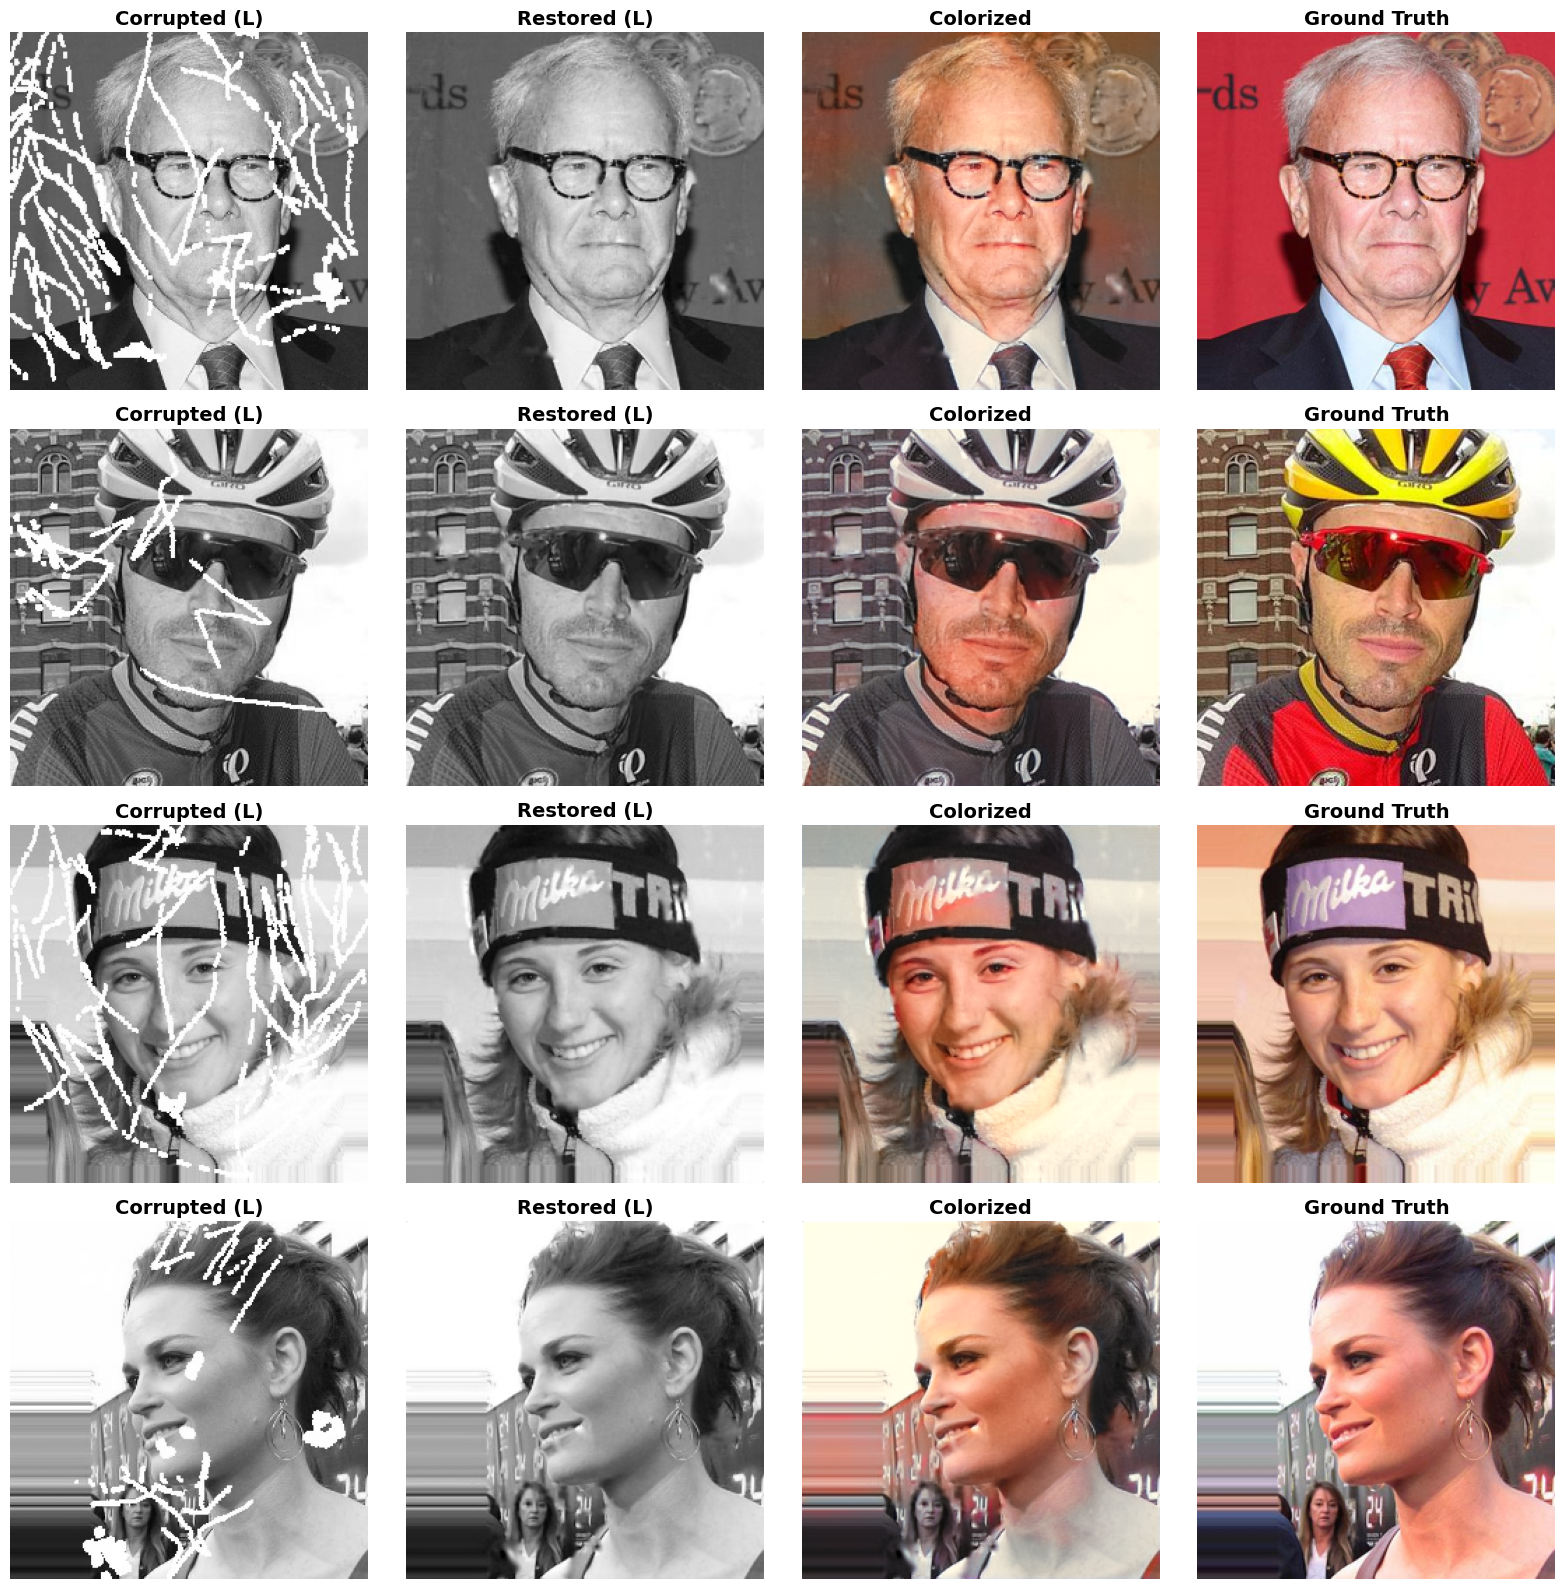

In [20]:
visualize_from_results(
    all_results,
    num_samples=4
)

In [56]:
class InferenceDateset(Dataset):
    def __init__(self, degraded_dir, image_size=256):
        self.degraded_dir = degraded_dir
        self.image_size = image_size
        
        self.degraded_paths = [os.path.join(degraded_dir, f) for f in os.listdir(degraded_dir)]
        self.degraded_paths = sorted(self.degraded_paths)
    
        print(f"All images will be resized to {image_size}x{image_size}")
        
    def __len__(self):
        return len(self.degraded_paths)
    
    def __getitem__(self, idx):
        degraded = Image.open(self.degraded_paths[idx]).convert('L')
        degraded = degraded.resize((self.image_size, self.image_size), Image.BICUBIC)
        degraded = torch.from_numpy(np.array(degraded)).float().unsqueeze(0) / 255.0
        return degraded  # [1, 256, 256]

In [65]:
degraded_dir = '/kaggle/input/datasets/coinlord/eval-samples'

inference_dataset = InferenceDateset(degraded_dir, image_size = 256)
inference_loader = DataLoader(
    inference_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=2
)


All images will be resized to 256x256


In [69]:
def inference(
    restoration_model,
    colorization_model,
    loader,
):
    restoration_model.eval()
    colorization_model.eval()
    
    all_results = []

    with torch.no_grad():
        for idx, L_corrupted in enumerate(loader):
            L_corrupted = L_corrupted.to(DEVICE)        # 16 x 1 x 256 x 256  each [0, 1]
            L_restored = restoration_model(L_corrupted) # 16 x 1 x 256 x 256  each [0, 1]
    
            # renormalize
            L_restored_norm = (L_restored - 0.5) * 2     # 16 x 1 x 256 x 256  each [-1, 1]
            ab_gen = colorization_model(L_restored_norm) # 16 x 2 x 256 x 256  each [-1, 1]
            
            batch_result = {
                    'L_corrupted': L_corrupted.cpu(),         # 16 x 1 x 256 x 256  each [0, 1]
                    'L_restored': L_restored.cpu(),           # 16 x 1 x 256 x 256  each [0, 1]
                    'L_restored_norm': L_restored_norm.cpu(), # 16 x 1 x 256 x 256  each [-1, 1]
                    'ab_generated': ab_gen.cpu(),             # 16 x 2 x 256 x 256  each [-1, 1]   
                }

            all_results.append(batch_result)
    
    return all_results

In [70]:
inference_results = evaluation(
    restoration_model,
    colorization_model,
    inference_loader
)

In [76]:
def visualize_from_old(
    results,
    num_samples=4,
    batch_index = 0
):
    batch = results[batch_index]
    
    L_corrupted = batch['L_corrupted'][:num_samples]
    L_restored = batch['L_restored'][:num_samples]
    ab_gen = batch['ab_generated'][:num_samples]
    
    L_restored_display = L_restored * 100.0  # [0, 100]
    ab_gen_denorm = ab_gen * 128.0           # [-128, 127]
    
    fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4 * num_samples))
    
    if num_samples == 1:
        axes = axes.reshape(1, -1)
    
    titles = ['Corrupted (L)', 'Restored (L)', 'Colorized', 'Ground Truth']
    
    for i in range(num_samples):
        # Corrupted L 
        corrupted_L = L_corrupted[i, 0].numpy()
        axes[i, 0].imshow(corrupted_L, cmap='gray', vmin=0, vmax=1)
        axes[i, 0].set_title(titles[0], fontsize=14, fontweight='bold')
        axes[i, 0].axis('off')
        
        # Restored L
        restored_L = L_restored[i, 0].numpy()
        axes[i, 1].imshow(restored_L, cmap='gray', vmin=0, vmax=1)
        axes[i, 1].set_title(titles[1], fontsize=14, fontweight='bold')
        axes[i, 1].axis('off')
        
        # Colorized 
        lab_result = torch.cat([
            L_restored_display[i],         # 256 x 256 x 1 each [0, 100]
            ab_gen_denorm[i]               # 256 x 256 x 2 each [-128, 127]
        ], dim=0).permute(1, 2, 0).numpy() # 256 x 256 x 3

        bgr_result = cv2.cvtColor(lab_result, cv2.COLOR_Lab2BGR) # [0, 100] [-128, 127] [-128, 127] -> [0, 1] [0, 1] [0, 1]
        rgb_result = cv2.cvtColor(bgr_result, cv2.COLOR_BGR2RGB) # [0, 1] [0, 1] [0, 1] -> [0, 1] [0, 1] [0, 1]
        rgb_result = np.clip(rgb_result, 0, 1)
        
        axes[i, 2].imshow(rgb_result) # 256 x 256 x 3 each [0, 1]
        axes[i, 2].set_title(titles[2], fontsize=14, fontweight='bold')
        axes[i, 2].axis('off')
    
    plt.tight_layout()
    plt.show()

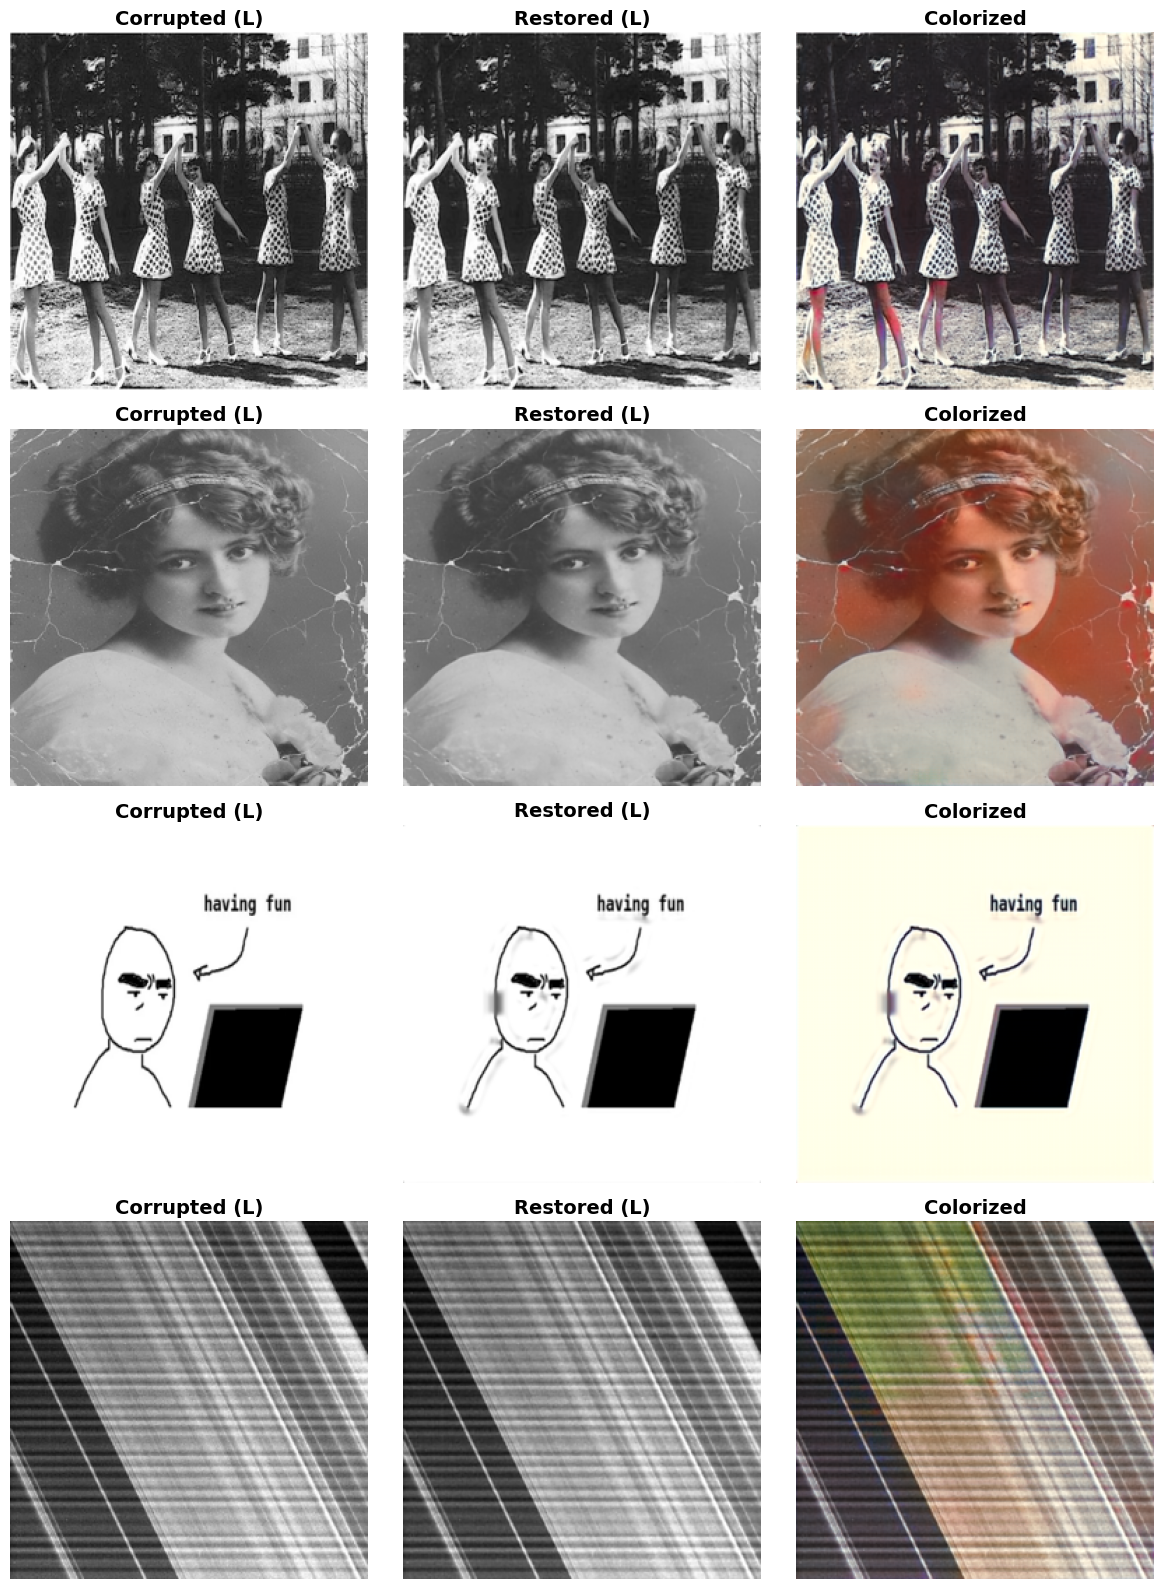

In [78]:
visualize_from_old(
    inference_results,
    num_samples=4,
    batch_index = 1
)